bloob brain barrier penetration BBBP
 here we will have binary outcome :
 1 = can cross blood-brain barrier
 0 = cannot cross blood-brain barrier
  so hence its classification problem not regression.
  and evaluation metric changes from RMSE to ROC - AUC 

Source: MoleculeNet BBBP dataset
https://pmc.ncbi.nlm.nih.gov/articles/PMC5868307/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix

print("imports done")

imports done


In [3]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())

Shape: (2050, 4)
   num                  name  p_np  \
0    1            Propanolol     1   
1    2  Terbutylchlorambucil     1   
2    3                 40730     1   
3    4                    24     1   
4    5           cloxacillin     1   

                                              smiles  
0                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12  
1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl  
2  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...  
3                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C  
4  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...  


In [4]:
print("Class distribution:")
print(df['p_np'].value_counts())
print()
print("Percentage:")
print(df['p_np'].value_counts(normalize=True).round(2) * 100)

Class distribution:
p_np
1    1567
0     483
Name: count, dtype: int64

Percentage:
p_np
1    76.0
0    24.0
Name: proportion, dtype: float64


This 76/24 split is imbalanced 
because a dumb model that predicts 1 for all molecule will be 76% acccurate but its never learning anything actually.
this is why we use ROC AUC instead of accuracy it measures how well the model seprates two classes not just how oftenit guesses correctly 


In [5]:
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

features = []
for smiles in df['smiles']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = fp_gen.GetFingerprint(mol)
        arr = np.zeros((2048,))
        DataStructs.ConvertToNumpyArray(fp, arr)
        features.append(arr)
    else:
        features.append(np.zeros(2048))

X = np.array(features)
y = df['p_np'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

[14:47:56] Explicit valence for atom # 1 N, 4, is greater than permitted
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] Explicit valence for atom # 11 N, 4, is greater than pe

X shape: (2050, 2048)
y shape: (2050,)


[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not removing hydrogen atom without neighbors
[14:47:56] WARNING: not r

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Verify balance is maintained
unique, counts = np.unique(y_test, return_counts=True)
print("Test set class distribution:", dict(zip(unique, counts)))

Training samples: 1640
Testing samples: 410
Test set class distribution: {np.int64(0): np.int64(97), np.int64(1): np.int64(313)}


In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Use predict_proba not predict
probs = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.9156


result :

roc auc 0.915 that means it separates BBB penetrating molecules from non-penetrating ones 91.5% of the time
which is consistent with published bentchmark of approximate 0.90

Source: Wu et al., MoleculeNet (2018)
https://pmc.ncbi.nlm.nih.gov/articles/PMC5868307/

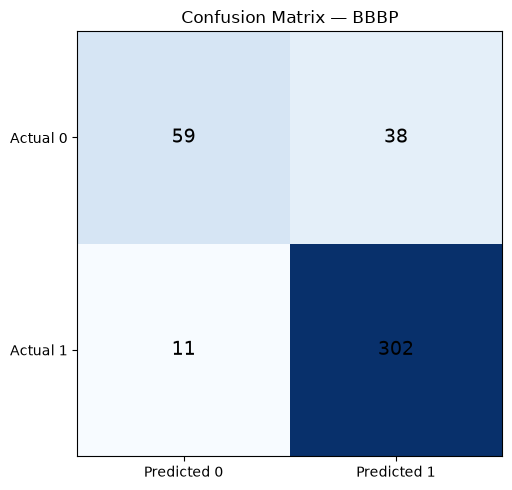

In [8]:
preds = rf.predict(X_test)
cm = confusion_matrix(y_test, preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', 
                fontsize=14, color='black')

plt.title("Confusion Matrix — BBBP")
plt.tight_layout()
plt.show()

correct predictions here out of 410 are 59+302 that is 88% accuracy 
false positive were 38 that is cant cross barrier but wrong predicted 
false negative were 11 that is can cross but predicted as cant  
so this model leans towards predicting 1 when uncertian 
In a real drug discovery pipeline, False Negatives are more costly 
missing a molecule that actually could be an effective CNS drug is 
worse than testing one extra molecule that turns out not to work.
This model currently favors caution in the right direction.